In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# load top 10,000 words
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

In [7]:
# create dataframe
df_train = pd.DataFrame({
    'review': x_train,
    'sentiment': y_train
})

df_test = pd.DataFrame({
    'review': x_test,
    'sentiment': y_test
})
df_train.head()

,review,sentiment
0,"[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, ...",1
1,"[1, 194, 1153, 194, 8255, 78, 228, 5, 6, 1463,...",0
2,"[1, 14, 47, 8, 30, 31, 7, 4, 249, 108, 7, 4, 5...",0
3,"[1, 4, 2, 2, 33, 2804, 4, 2040, 432, 111, 153,...",1
4,"[1, 249, 1323, 7, 61, 113, 10, 10, 13, 1637, 1...",0


In [11]:
word_index = imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}

def decode_review(encoded_review):
    return " ".join([reverse_word_index.get(i - 3, "?") for i in encoded_review])

# add decoded text column
df_train['review_text'] = df_train['review'].apply(decode_review)

# print sample
print(df_train[['review_text', 'sentiment']].head())

                                         review_text  sentiment
0  ? this film was just brilliant casting locatio...          1
1  ? big hair big boobs bad music and a giant saf...          0
2  ? this has to be one of the worst films of the...          0
3  ? the ? ? at storytelling the traditional sort...          1
4  ? worst mistake of my life br br i picked this...          0


## Prepare Data for Model

In [13]:
max_len = 200

# pad sequences
x_train = pad_sequences(df_train['review'], maxlen=max_len)
y_train = df_train['sentiment'].values

x_test = pad_sequences(df_test['review'], maxlen=max_len)
y_test = df_test['sentiment'].values

## Build RNN (LSTM Model)

In [14]:
model = models.Sequential([
    layers.Embedding(vocab_size, 128, input_length=max_len),
    layers.LSTM(64),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

C:\Users\Rohan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [15]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 82ms/step - accuracy: 0.6976 - loss: 0.5517 - val_accuracy: 0.8486 - val_loss: 0.3968
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step - accuracy: 0.8995 - loss: 0.2579 - val_accuracy: 0.8734 - val_loss: 0.3032
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 84ms/step - accuracy: 0.9407 - loss: 0.1643 - val_accuracy: 0.8792 - val_loss: 0.3353
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 84ms/step - accuracy: 0.9609 - loss: 0.1125 - val_accuracy: 0.8574 - val_loss: 0.4107
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step - accuracy: 0.9632 - loss: 0.1013 - val_accuracy: 0.8542 - val_loss: 0.4672


In [17]:
loss, acc = model.evaluate(x_test, y_test)
print("Accuracy:", acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.8460 - loss: 0.4967
Accuracy: 0.8457199931144714


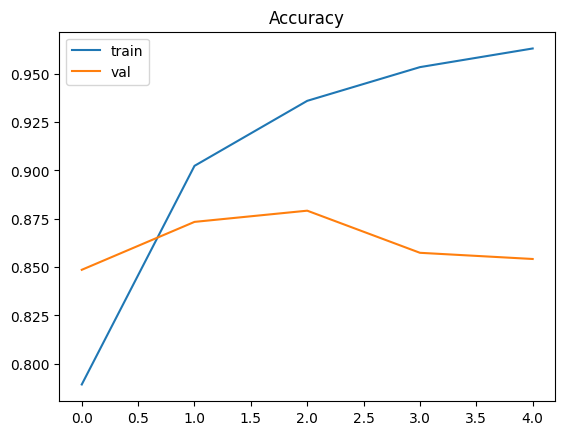

In [18]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

In [19]:
index = 0

sample = x_test[index]
pred = model.predict(sample.reshape(1, -1))

print("Review:\n")
print(df_test.iloc[index]['review'])  # encoded

print("\nDecoded Review:\n")
print(decode_review(df_test.iloc[index]['review']))

print("\nPredicted:", "Positive" if pred > 0.5 else "Negative")
print("Actual:", "Positive" if y_test[index] == 1 else "Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
Review:

[1, 591, 202, 14, 31, 6, 717, 10, 10, 2, 2, 5, 4, 360, 7, 4, 177, 5760, 394, 354, 4, 123, 9, 1035, 1035, 1035, 10, 10, 13, 92, 124, 89, 488, 7944, 100, 28, 1668, 14, 31, 23, 27, 7479, 29, 220, 468, 8, 124, 14, 286, 170, 8, 157, 46, 5, 27, 239, 16, 179, 2, 38, 32, 25, 7944, 451, 202, 14, 6, 717]

Decoded Review:

? please give this one a miss br br ? ? and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite ? so all you madison fans give this a miss

Predicted: Negative
Actual: Negative
